In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [4]:
dataset = pd.read_csv('dataset.csv')

In [5]:
dataset.head()

,Ad 1,Ad 2,Ad 3,Ad 4,Ad 5,Ad 6,Ad 7,Ad 8,Ad 9,Ad 10
0,1,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0


In [6]:
dataset.shape

(10000, 10)

In [9]:
import math
observations = 10000
no_of_Ads = 10
ads_selected = []
numbers_of_selections_of_each_ads = [0] * no_of_Ads
sums_of_rewards_of_each_ads = [0] * no_of_Ads
total_reward = 0
for n in range(0, observations):
    ad = 0
    max_upper_bound = 0
    for i in range(0, no_of_Ads):
        if (numbers_of_selections_of_each_ads[i] > 0):
            average_reward = sums_of_rewards_of_each_ads[i] / numbers_of_selections_of_each_ads[i]
            delta_i = math.sqrt(3/2 * math.log(n + 1) / numbers_of_selections_of_each_ads[i])
            upper_bound = average_reward + delta_i
        else:
            upper_bound = 1e400
        if upper_bound > max_upper_bound:
            max_upper_bound = upper_bound
            ad = i
    ads_selected.append(ad)
    numbers_of_selections_of_each_ads[ad] = numbers_of_selections_of_each_ads[ad] + 1
    reward = dataset.values[n, ad]
    sums_of_rewards_of_each_ads[ad] = sums_of_rewards_of_each_ads[ad] + reward
    total_reward = total_reward + reward

print("Rewards by Ads = ",sums_of_rewards_of_each_ads)
print("Total Rewards by UCB = ",total_reward)
print("Ads selected at each round:",ads_selected)

Rewards by Ads =  [np.int64(120), np.int64(47), np.int64(7), np.int64(38), np.int64(1675), np.int64(1), np.int64(27), np.int64(236), np.int64(20), np.int64(7)]
Total Rewards by UCB =  2178
Ads selected at each round: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 8, 9, 0, 8, 1, 2, 3, 4, 5, 6, 6, 7, 7, 7, 9, 7, 0, 6, 8, 1, 2, 3, 4, 4, 4, 4, 4, 5, 9, 7, 0, 0, 6, 8, 4, 0, 7, 1, 1, 2, 3, 5, 9, 4, 1, 6, 8, 0, 7, 2, 3, 5, 9, 4, 1, 6, 8, 0, 7, 7, 7, 7, 7, 7, 4, 2, 3, 5, 9, 1, 6, 8, 0, 0, 7, 0, 4, 1, 6, 8, 2, 3, 5, 9, 7, 0, 4, 4, 4, 7, 7, 7, 7, 1, 6, 8, 2, 3, 5, 9, 0, 7, 7, 4, 7, 7, 7, 1, 6, 8, 0, 4, 4, 2, 3, 5, 9, 4, 7, 0, 7, 1, 1, 1, 6, 6, 6, 6, 6, 8, 4, 2, 3, 5, 9, 7, 7, 7, 0, 6, 4, 1, 1, 1, 8, 7, 2, 3, 5, 9, 4, 0, 1, 1, 1, 6, 7, 8, 4, 1, 2, 3, 5, 9, 0, 6, 7, 8, 4, 7, 1, 0, 6, 2, 3, 5, 9, 7, 7, 7, 7, 4, 4, 4, 4, 4, 7, 8, 1, 0, 6, 6, 6, 7, 4, 2, 3, 5, 9, 1, 6, 8, 7, 0, 4, 4, 4, 4, 4, 2, 3, 5, 9, 1, 6, 7, 4, 8, 0, 7, 4, 4, 4, 1, 6, 2, 3, 5, 9, 0, 0,

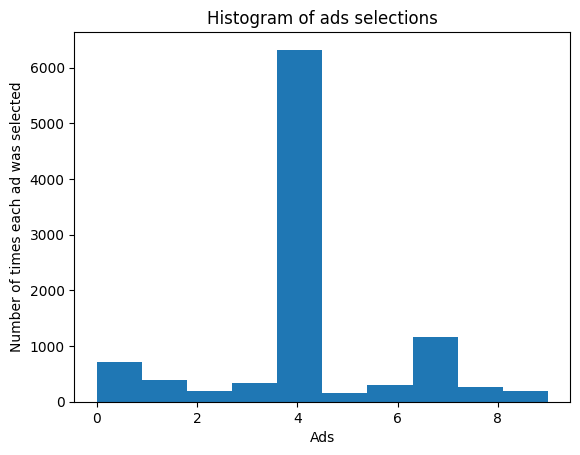

In [10]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()

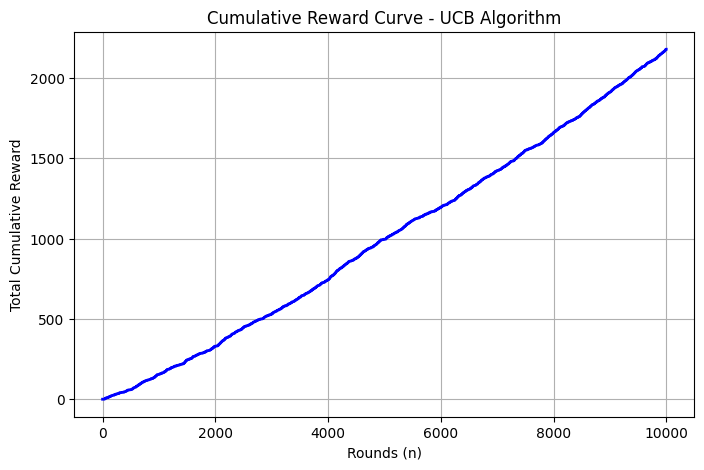

In [11]:
# ----- Compute cumulative reward -----
cumulative_rewards = []
running_total = 0
for n in range(observations):
    ad = ads_selected[n]
    reward = dataset.values[n, ad]
    running_total += reward
    cumulative_rewards.append(running_total)

# ----- Plot cumulative reward curve -----
plt.figure(figsize=(8,5))
plt.plot(range(observations), cumulative_rewards, color='blue', linewidth=2)
plt.title('Cumulative Reward Curve - UCB Algorithm')
plt.xlabel('Rounds (n)')
plt.ylabel('Total Cumulative Reward')
plt.grid(True)
plt.show()